# **UTS Prediksi Modern & Machine Learning**
## Experiment Challenge: Credit Default Prediction

**Nama:** Ikkhil Ghina Nabila
**NIM:** 2404220008
**Program Studi:** Statistika dan Sains Data  
**Universitas:** Universitas Negeri Semarang

### Tujuan
Membangun dan membandingkan beberapa model machine learning untuk memprediksi
apakah nasabah akan mengalami default pembayaran kartu kredit pada bulan berikutnya.

### Target
`default.payment.next.month`

- 0 = Tidak mengalami default
- 1 = Mengalami default

**Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Agar hasil eksperimen dapat direproduksi
RANDOM_STATE = 42

print("Library berhasil di-import.")

Library berhasil di-import.


**Experiment 0 — Data Understanding & Preparation**

In [2]:
# Tentukan path file dataset terlebih dahulu
file_path = "/content/UCI_Credit_Card.csv"

# Membaca header secara manual karena format header CSV
# memiliki tanda kutip ganda berlebih
with open(file_path, "r", encoding="utf-8-sig") as f:
    header_line = f.readline().strip()

# Membersihkan tanda kutip ganda pada header
columns = header_line.replace('"', '').split(',')

# Membaca data mulai dari baris kedua
df = pd.read_csv(
    file_path,
    skiprows=1,
    header=None,
    names=columns
)

print("Dataset berhasil dibaca.")
print(f"Jumlah baris   : {df.shape[0]:,}")
print(f"Jumlah kolom   : {df.shape[1]}")

Dataset berhasil dibaca.
Jumlah baris   : 30,000
Jumlah kolom   : 25


In [3]:
# Melihat 5 baris pertama
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
# Melihat 5 baris terakhir
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1
29999,30000,50000.0,1,2,1,46,0,0,0,0,...,36535.0,32428.0,15313.0,2078.0,1800.0,1430.0,1000.0,1000.0,1000.0,1


In [5]:
# DATASET DIMENSION

print("Dimensi dataset:", df.shape)
print(f"Jumlah observasi : {df.shape[0]:,}")
print(f"Jumlah variabel  : {df.shape[1]}")

Dimensi dataset: (30000, 25)
Jumlah observasi : 30,000
Jumlah variabel  : 25


In [6]:
# DATA STRUCTURE

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [7]:
# Ringkasan tipe data
print("\nTipe data setiap variabel:")
print(df.dtypes)


Tipe data setiap variabel:
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object


**Statistik Deskriptif**

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


**Cek Missing Value**

In [9]:
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Value": missing,
    "Percentage (%)": (missing / len(df) * 100).round(2)
})

missing_table

,Missing Value,Percentage (%)
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


In [10]:
print("Total missing value:", df.isnull().sum().sum())

Total missing value: 0


**Cek Duplicate**

In [11]:
duplicate_count = df.duplicated().sum()

print("Jumlah duplicate:", duplicate_count)

Jumlah duplicate: 0


**Cek Nilai Tidak Wajar**

In [12]:
# UNIQUE VALUES

categorical_like = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "default.payment.next.month"
]

for col in categorical_like:
    print(f"\n{col}")
    print(sorted(df[col].unique()))


SEX
[np.int64(1), np.int64(2)]

EDUCATION
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

MARRIAGE
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

PAY_0
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_2
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_3
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_4
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_5
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_6
[np.int64(-2), np.int64(-1), np.int64(0), n

In [13]:
# CHECK NUMERIC RANGES

print("Rentang AGE:")
print("Minimum:", df["AGE"].min())
print("Maximum:", df["AGE"].max())

print("\nRentang LIMIT_BAL:")
print("Minimum:", df["LIMIT_BAL"].min())
print("Maximum:", df["LIMIT_BAL"].max())

Rentang AGE:
Minimum: 21
Maximum: 79

Rentang LIMIT_BAL:
Minimum: 10000.0
Maximum: 1000000.0


**Distribusi Target**

In [14]:
# TARGET DISTRIBUTION

target = "default.payment.next.month"

target_count = df[target].value_counts().sort_index()

target_percentage = (
    df[target]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Jumlah": target_count,
    "Persentase (%)": target_percentage
})

target_summary

,Jumlah,Persentase (%)
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


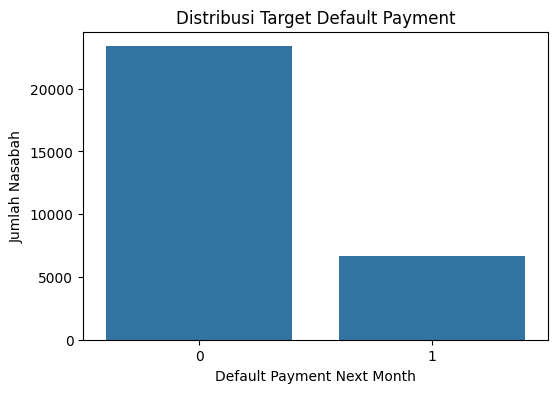

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=target
)

plt.title("Distribusi Target Default Payment")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Jumlah Nasabah")

plt.show()

**Cek variabel kategorik**

In [16]:
categorical_check = ["SEX", "EDUCATION", "MARRIAGE"]

for col in categorical_check:
    print(f"\n===== {col} =====")
    print(df[col].value_counts().sort_index())


===== SEX =====
SEX
1    11888
2    18112
Name: count, dtype: int64

===== EDUCATION =====
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

===== MARRIAGE =====
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


**Cek PAY_0 sampai PAY_6**

In [17]:
pay_variables = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

for col in pay_variables:
    print(f"\n===== {col} =====")
    print(df[col].value_counts().sort_index())


===== PAY_0 =====
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

===== PAY_2 =====
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

===== PAY_3 =====
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

===== PAY_4 =====
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

===== PAY_5 =====
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

===== PAY_6 =====
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49


**Cek rentang variabel numerik**

In [18]:
numeric_summary = pd.DataFrame({
    "Minimum": df.min(),
    "Maximum": df.max(),
    "Mean": df.mean(),
    "Median": df.median()
})

numeric_summary.round(2)

,Minimum,Maximum,Mean,Median
ID,1.0,30000.0,15000.50,15000.5
LIMIT_BAL,10000.0,1000000.0,167484.32,140000.0
SEX,1.0,2.0,1.60,2.0
EDUCATION,0.0,6.0,1.85,2.0
MARRIAGE,0.0,3.0,1.55,2.0
AGE,21.0,79.0,35.49,34.0
PAY_0,-2.0,8.0,-0.02,0.0
PAY_2,-2.0,8.0,-0.13,0.0
PAY_3,-2.0,8.0,-0.17,0.0
PAY_4,-2.0,8.0,-0.22,0.0


**Cek ID**

In [19]:
print("Jumlah ID unik:", df["ID"].nunique())
print("Jumlah observasi:", len(df))

if df["ID"].nunique() == len(df):
    print("Setiap observasi memiliki ID yang unik.")
else:
    print("Terdapat ID yang duplikat.")

Jumlah ID unik: 30000
Jumlah observasi: 30000
Setiap observasi memiliki ID yang unik.


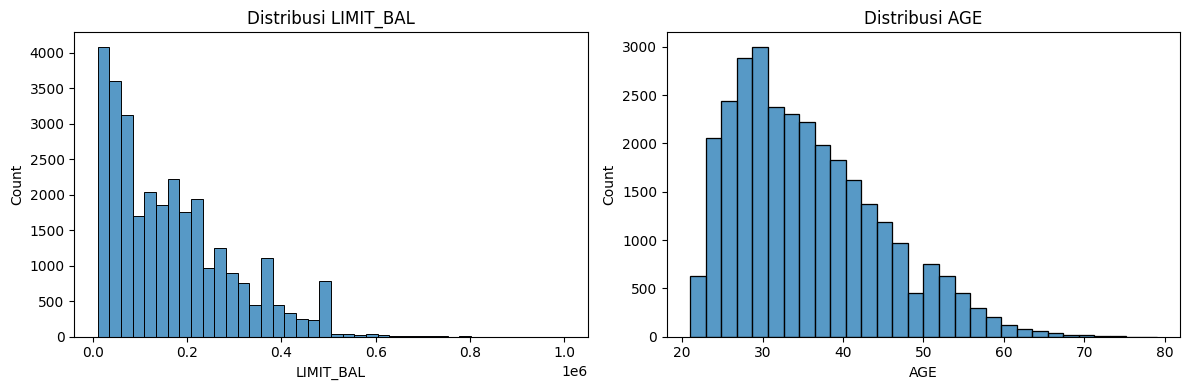

In [54]:
# Distribusi LIMIT_BAL dan AGE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["LIMIT_BAL"], bins=40, ax=axes[0])
axes[0].set_title("Distribusi LIMIT_BAL")
sns.histplot(df["AGE"], bins=30, ax=axes[1])
axes[1].set_title("Distribusi AGE")
plt.tight_layout()
plt.show()

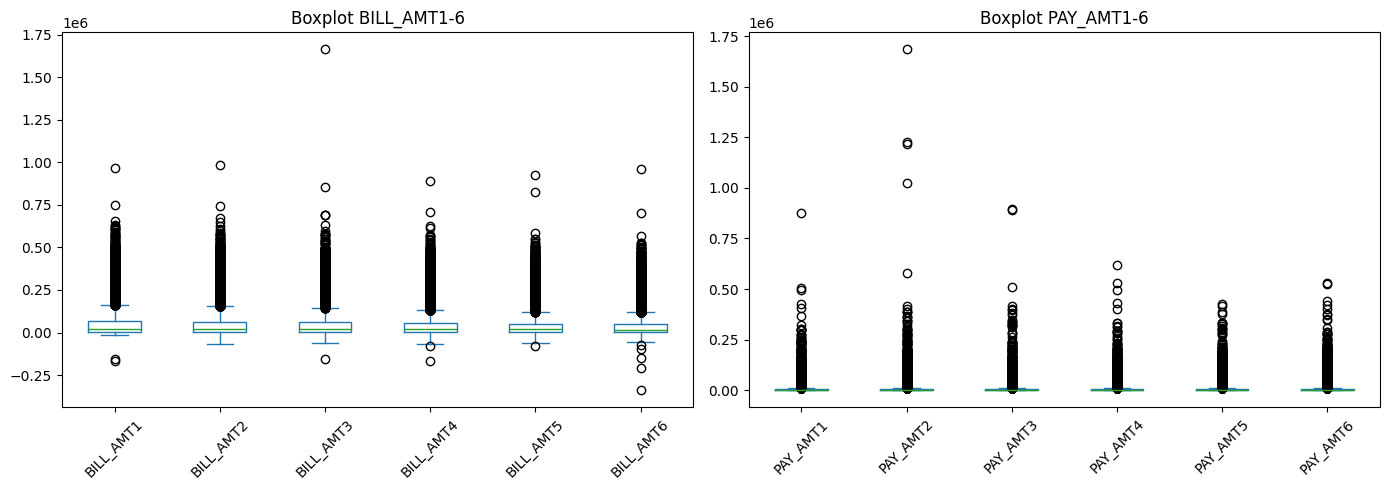

In [55]:
# Boxplot BILL_AMT dan PAY_AMT
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
payamt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[bill_cols].plot(kind="box", ax=axes[0], rot=45, title="Boxplot BILL_AMT1-6")
df[payamt_cols].plot(kind="box", ax=axes[1], rot=45, title="Boxplot PAY_AMT1-6")
plt.tight_layout()
plt.show()

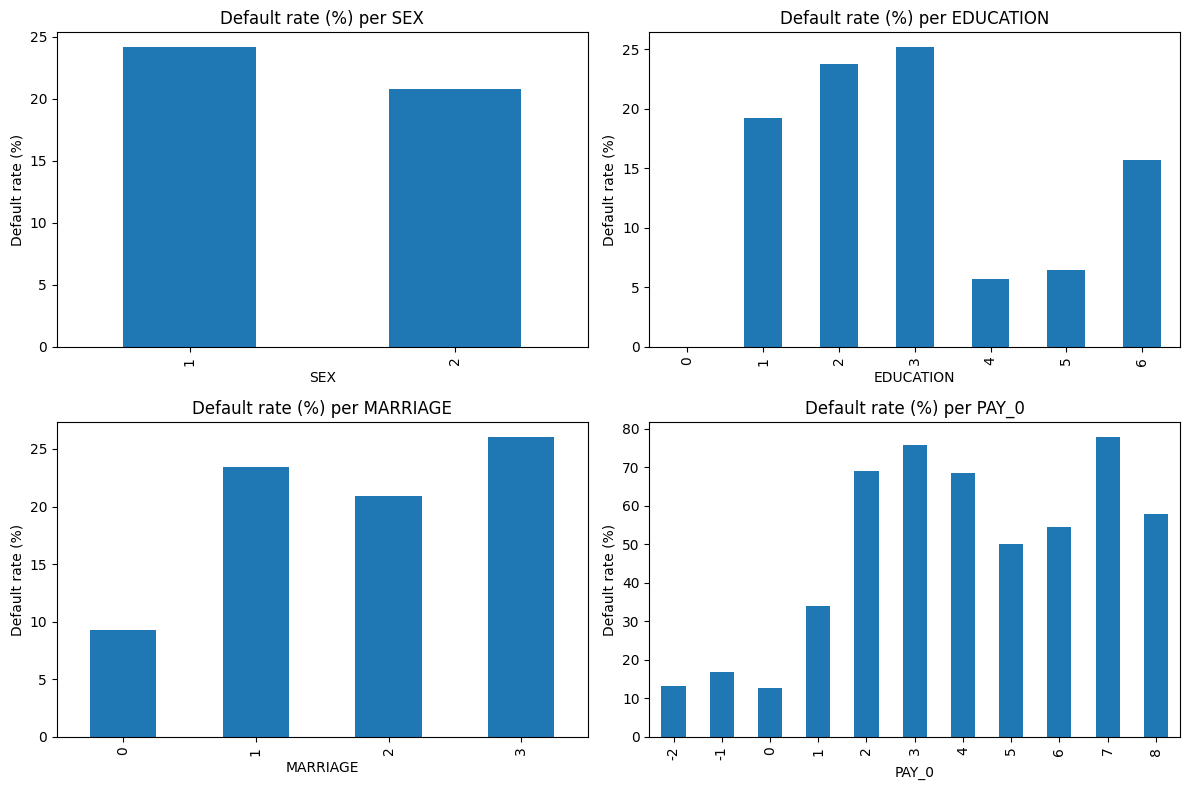

In [56]:
# Default rate per kategori / status pembayaran
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["SEX", "EDUCATION", "MARRIAGE", "PAY_0"]):
    rate = df.groupby(col)[target].mean().mul(100)
    rate.plot(kind="bar", ax=ax)
    ax.set_title(f"Default rate (%) per {col}")
    ax.set_ylabel("Default rate (%)")
plt.tight_layout()
plt.show()

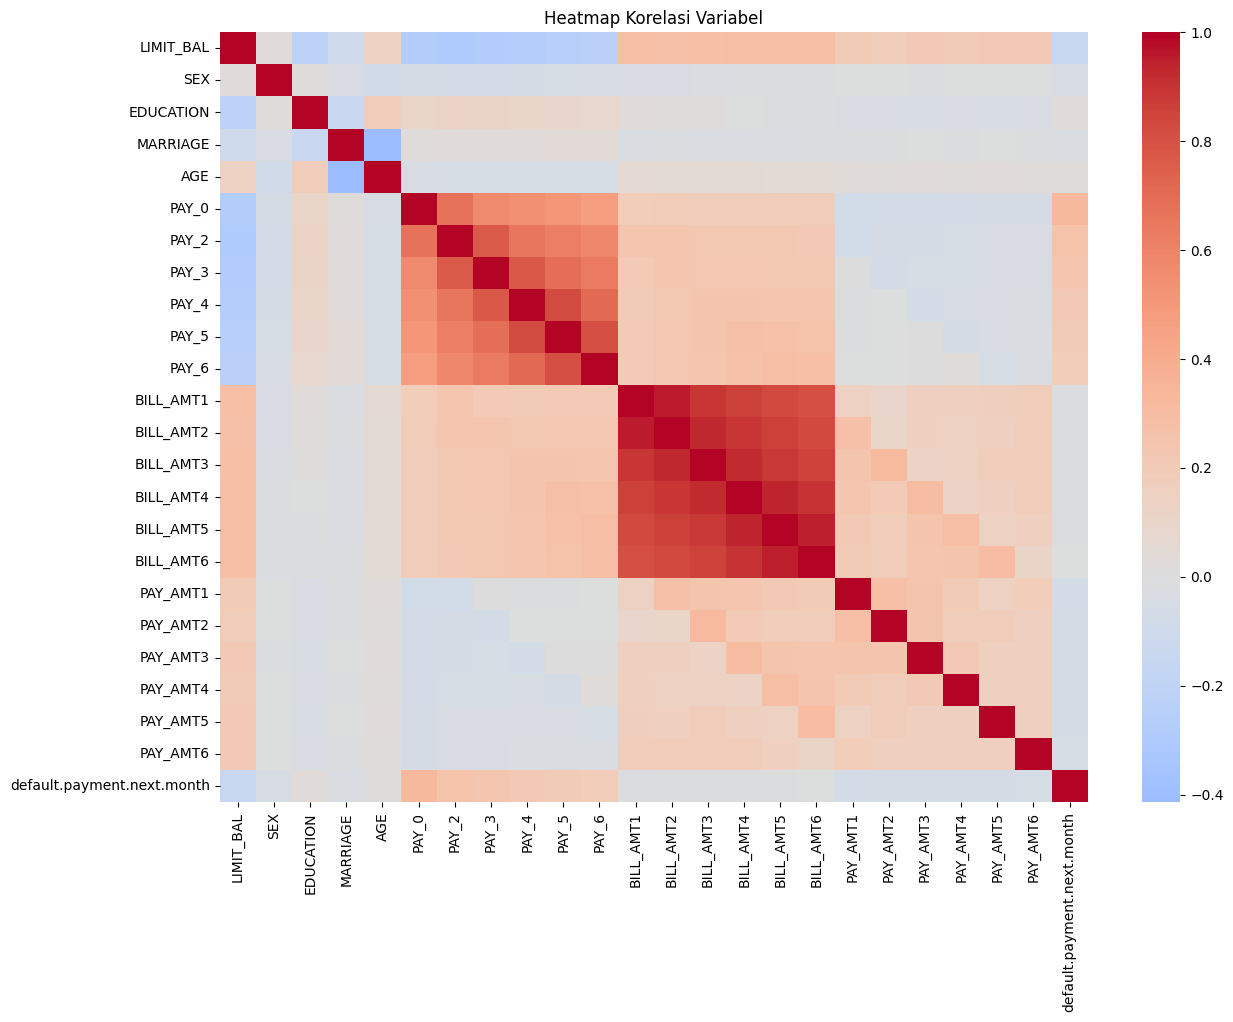

10 variabel dengan korelasi (absolut) tertinggi terhadap target:
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT4    -0.057
Name: default.payment.next.month, dtype: float64


In [57]:
# Korelasi antar variabel
corr = df.drop(columns=["ID"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Variabel")
plt.show()

print("10 variabel dengan korelasi (absolut) tertinggi terhadap target:")
print(corr[target].drop(target).sort_values(key=abs, ascending=False).head(10).round(3))

In [58]:
# Outlier (metode IQR) dan nilai negatif pada BILL_AMT
num_cols_check = ["LIMIT_BAL", "AGE"] + bill_cols + payamt_cols

rows = []
for col in num_cols_check:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    rows.append({
        "Variabel": col,
        "Jumlah outlier (IQR)": n_out,
        "Persentase (%)": round(n_out / len(df) * 100, 2)
    })

display(pd.DataFrame(rows))

print("\nJumlah nilai negatif pada BILL_AMT:")
print((df[bill_cols] < 0).sum())

,Variabel,Jumlah outlier (IQR),Persentase (%)
0,LIMIT_BAL,167,0.56
1,AGE,272,0.91
2,BILL_AMT1,2400,8.00
3,BILL_AMT2,2395,7.98
4,BILL_AMT3,2469,8.23
5,BILL_AMT4,2622,8.74
6,BILL_AMT5,2725,9.08
7,BILL_AMT6,2693,8.98
8,PAY_AMT1,2745,9.15
9,PAY_AMT2,2714,9.05



Jumlah nilai negatif pada BILL_AMT:
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64


In [59]:
# Fungsi pembersihan kategori (dipakai di dalam Pipeline mulai Experiment 2)
def clean_categories(X):
    X = X.copy()
    X["EDUCATION"] = X["EDUCATION"].replace({0: 4, 5: 4, 6: 4})   # kode tidak terdokumentasi -> others
    X["MARRIAGE"] = X["MARRIAGE"].replace({0: 3})                 # kode tidak terdokumentasi -> others
    return X

# Demonstrasi pada salinan data (df asli tidak diubah)
demo_clean = clean_categories(df)
print("EDUCATION sesudah dibersihkan:")
print(demo_clean["EDUCATION"].value_counts().sort_index())
print("\nMARRIAGE sesudah dibersihkan:")
print(demo_clean["MARRIAGE"].value_counts().sort_index())

EDUCATION sesudah dibersihkan:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE sesudah dibersihkan:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [20]:
# Menentukan kelompok variabel berdasarkan karakteristik data

categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

pay_features = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

numeric_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

print("Categorical:", categorical_features)
print("PAY variables:", pay_features)
print("Numerical:", numeric_features)
print("Total predictor:", len(categorical_features) + len(pay_features) + len(numeric_features))

Categorical: ['SEX', 'EDUCATION', 'MARRIAGE']
PAY variables: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numerical: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Total predictor: 23


**Menentukan Predictor dan Target**

In [21]:
# Menentukan predictor (X) dan target (y)

target = "default.payment.next.month"

X = df.drop(columns=[target, "ID"])
y = df[target]

print("Target:", target)
print("Jumlah predictor:", X.shape[1])
print("Jumlah observasi:", X.shape[0])

Target: default.payment.next.month
Jumlah predictor: 23
Jumlah observasi: 30000


**Train-Test Split (80:20)**

In [22]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Ukuran data training :", X_train.shape)
print("Ukuran data testing  :", X_test.shape)
print("Jumlah target training:", y_train.shape)
print("Jumlah target testing :", y_test.shape)

Ukuran data training : (24000, 23)
Ukuran data testing  : (6000, 23)
Jumlah target training: (24000,)
Jumlah target testing : (6000,)


**Cek proporsi target setelah split**

In [23]:
# Membandingkan proporsi target sebelum dan sesudah split

print("Proporsi target seluruh data:")
print(y.value_counts(normalize=True).sort_index())

print("\nProporsi target training:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nProporsi target testing:")
print(y_test.value_counts(normalize=True).sort_index())

Proporsi target seluruh data:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Proporsi target training:
default.payment.next.month
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Proporsi target testing:
default.payment.next.month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


**Membuat CV**

In [24]:
# 5-FOLD STRATIFIED CROSS VALIDATION

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-Fold Stratified Cross Validation siap digunakan.")

5-Fold Stratified Cross Validation siap digunakan.


In [65]:
from sklearn import clone

METRIC_COLS = ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]

def evaluate_model(name, model):
    """5-fold Stratified CV (F1) pada training set, lalu fit pada seluruh training set
    dan evaluasi pada test set."""
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    fitted = clone(model).fit(X_train, y_train)
    y_pred = fitted.predict(X_test)
    return {
        "Model": name,
        "CV F1": cv_scores.mean(),
        "CV F1 Std": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
        "_model": fitted,
        "_pred": y_pred,
    }

def to_table(results):
    """Ubah list hasil evaluate_model menjadi DataFrame (tanpa objek model)."""
    return pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in results])

def metrics_of(r):
    """Ambil 5 metrik utama dari satu hasil."""
    return {m: r[m] for m in METRIC_COLS}

print("Fungsi bantu siap digunakan setelah menambahkan import clone.")

Fungsi bantu siap digunakan setelah menambahkan import clone.


**Import Model dan Metrik**

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

**EXPERIMENT 1 — BASELINE MODEL**

In [26]:
# Experiment 1 - Baseline Logistic Regression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [27]:
# 5-Fold Cross Validation - F1 Score

cv_f1_baseline = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("F1-score setiap fold:")
print(cv_f1_baseline)

print("\nMean CV F1-score:", cv_f1_baseline.mean())
print("Std CV F1-score :", cv_f1_baseline.std())

F1-score setiap fold:
[0.40079893 0.33647571 0.31130064 0.34800839 0.36573759]

Mean CV F1-score: 0.3524642521329311
Std CV F1-score : 0.029941123712936935


In [28]:
# Prediksi pada test set

y_pred_baseline = baseline_model.predict(X_test)

In [29]:
# Evaluasi Baseline pada Test Set

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("=== Experiment 1: Baseline Logistic Regression ===")
print(f"CV F1-score  : {cv_f1_baseline.mean():.4f}")
print(f"Test Accuracy: {baseline_accuracy:.4f}")
print(f"Test Precision: {baseline_precision:.4f}")
print(f"Test Recall  : {baseline_recall:.4f}")
print(f"Test F1-score: {baseline_f1:.4f}")

=== Experiment 1: Baseline Logistic Regression ===
CV F1-score  : 0.3525
Test Accuracy: 0.8037
Test Precision: 0.6630
Test Recall  : 0.2283
Test F1-score: 0.3397


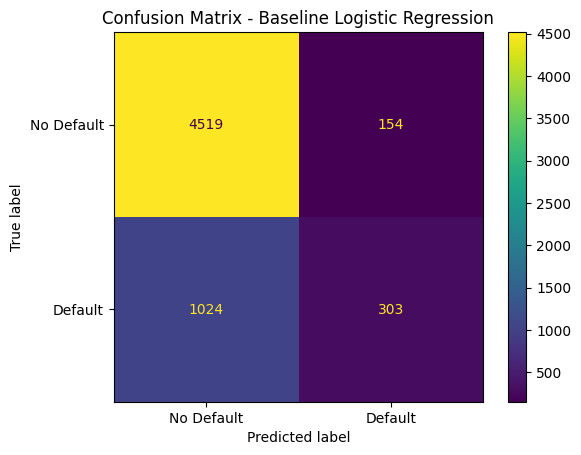

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
)

disp.plot()
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.show()

Accuracy 80,37%, tetapi Recall hanya 22,83% dan F1 hanya 0,3397.
Artinya, model cukup baik dalam klasifikasi secara keseluruhan, tetapi masih banyak nasabah yang sebenarnya default yang belum berhasil dikenali. Karena tugas kita menetapkan F1 sebagai metrik utama, kita tidak boleh menyimpulkan model bagus hanya karena Accuracy tinggi.

In [61]:
# Simpan hasil baseline dalam format yang seragam
m_exp1 = {
    "CV F1": cv_f1_baseline.mean(),
    "Test Accuracy": baseline_accuracy,
    "Test Precision": baseline_precision,
    "Test Recall": baseline_recall,
    "Test F1": baseline_f1
}
print("Std CV F1 baseline:", round(cv_f1_baseline.std(), 4))

Std CV F1 baseline: 0.0299


**Experiment 2 - Preprocessing**

In [62]:
# PAY_0..PAY_6 diperlakukan sebagai numerik ordinal (urutan keterlambatan bermakna)
numeric_features_exp2 = numeric_features + pay_features

def make_preprocessor(clean=True):
    ct = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features_exp2),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
    ])
    if clean:
        return Pipeline([
            ("clean", FunctionTransformer(clean_categories)),
            ("ct", ct)
        ])
    return ct

print("Numerical features:", numeric_features_exp2)
print("Categorical features:", categorical_features)
print("Total:", len(numeric_features_exp2) + len(categorical_features))

Numerical features: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Categorical features: ['SEX', 'EDUCATION', 'MARRIAGE']
Total: 23


In [66]:
from sklearn.preprocessing import FunctionTransformer

# Tiga varian preprocessing (semuanya Logistic Regression, supaya perbandingannya adil)
variants_exp2 = {
    "A: Scaling + OHE": Pipeline([
        ("preprocessor", make_preprocessor(clean=False)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "B: A + cleaning kategori": Pipeline([
        ("preprocessor", make_preprocessor(clean=True)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "C: B + class_weight balanced": Pipeline([
        ("preprocessor", make_preprocessor(clean=True)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
}

res_exp2_variants = [evaluate_model(n, m) for n, m in variants_exp2.items()]
to_table(res_exp2_variants)

,Model,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,A: Scaling + OHE,0.365869,0.014936,0.808667,0.690832,0.244160,0.360802
1,B: A + cleaning kategori,0.364131,0.015123,0.808833,0.692308,0.244160,0.361003
2,C: B + class_weight balanced,0.481241,0.011916,0.678667,0.367912,0.630746,0.464742


In [67]:
# Tabel ablation: baseline vs varian preprocessing
baseline_row = {"Model": "Exp 1: Baseline (data mentah)", "CV F1": m_exp1["CV F1"],
                "CV F1 Std": cv_f1_baseline.std(), **{k: m_exp1[k] for k in METRIC_COLS[1:]}}

exp2_ablation = pd.concat(
    [pd.DataFrame([baseline_row]), to_table(res_exp2_variants)],
    ignore_index=True
)
exp2_ablation.round(4)

,Model,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,Exp 1: Baseline (data mentah),0.3525,0.0299,0.8037,0.6630,0.2283,0.3397
1,A: Scaling + OHE,0.3659,0.0149,0.8087,0.6908,0.2442,0.3608
2,B: A + cleaning kategori,0.3641,0.0151,0.8088,0.6923,0.2442,0.3610
3,C: B + class_weight balanced,0.4812,0.0119,0.6787,0.3679,0.6307,0.4647


**Penentuan model Experiment 2:** varian **B** (scaling + encoding + cleaning kategori) dipakai sebagai
*Experiment 2 resmi* karena keputusan cleaning didasarkan pada Experiment 0 dan seluruhnya adalah preprocessing murni.
Varian **C** (`class_weight`) adalah penanganan imbalance, bukan preprocessing murni, sehingga dilaporkan
sebagai pembanding tambahan dan diuji kembali melalui grid hyperparameter pada Experiment 4.

In [68]:
# Experiment 2 resmi = varian B
res_exp2 = res_exp2_variants[1]
logistic_preprocessed = res_exp2["_model"]
y_pred_exp2 = res_exp2["_pred"]

cv_f1_exp2 = res_exp2["CV F1"]
exp2_accuracy = res_exp2["Test Accuracy"]
exp2_precision = res_exp2["Test Precision"]
exp2_recall = res_exp2["Test Recall"]
exp2_f1 = res_exp2["Test F1"]
m_exp2 = metrics_of(res_exp2)

print("=== Experiment 2: Logistic Regression + Preprocessing (varian B) ===")
print(f"CV F1-score   : {cv_f1_exp2:.4f}")
print(f"Test Accuracy : {exp2_accuracy:.4f}")
print(f"Test Precision: {exp2_precision:.4f}")
print(f"Test Recall   : {exp2_recall:.4f}")
print(f"Test F1-score : {exp2_f1:.4f}")

# Perbandingan Experiment 1 vs Experiment 2
comparison_exp1_exp2 = pd.DataFrame({
    "Metric": METRIC_COLS,
    "Experiment 1 - Baseline": [m_exp1[m] for m in METRIC_COLS],
    "Experiment 2 - Preprocessing": [m_exp2[m] for m in METRIC_COLS],
})
comparison_exp1_exp2["Selisih"] = (
    comparison_exp1_exp2["Experiment 2 - Preprocessing"] - comparison_exp1_exp2["Experiment 1 - Baseline"]
)
comparison_exp1_exp2.round(4)

=== Experiment 2: Logistic Regression + Preprocessing (varian B) ===
CV F1-score   : 0.3641
Test Accuracy : 0.8088
Test Precision: 0.6923
Test Recall   : 0.2442
Test F1-score : 0.3610


,Metric,Experiment 1 - Baseline,Experiment 2 - Preprocessing,Selisih
0,CV F1,0.3525,0.3641,0.0117
1,Test Accuracy,0.8037,0.8088,0.0052
2,Test Precision,0.6630,0.6923,0.0293
3,Test Recall,0.2283,0.2442,0.0158
4,Test F1,0.3397,0.3610,0.0213


In [69]:
# Jawaban otomatis Experiment 2 (angka diambil langsung dari hasil, bukan diketik manual)
d_cv = m_exp2["CV F1"] - m_exp1["CV F1"]
d_f1 = m_exp2["Test F1"] - m_exp1["Test F1"]
std_base = cv_f1_baseline.std()

print("Apakah preprocessing meningkatkan performa dibanding baseline?")
for m in METRIC_COLS:
    print(f"- {m:15s}: {m_exp1[m]:.4f} -> {m_exp2[m]:.4f} ({m_exp2[m]-m_exp1[m]:+.4f})")

if d_cv > 0 and d_f1 > 0:
    print("\nJawaban: YA, CV F1 dan Test F1 sama-sama meningkat.")
else:
    print("\nJawaban: TIDAK konsisten meningkat (CV F1 dan Test F1 tidak sama-sama naik).")

print(f"Catatan: kenaikan CV F1 = {d_cv:+.4f}, std CV F1 baseline = {std_base:.4f} -> "
      + ("kenaikan masih di dalam rentang variasi antar fold (dampak kecil)."
         if abs(d_cv) <= std_base else "kenaikan melampaui variasi antar fold."))

best_variant = exp2_ablation.loc[exp2_ablation["Model"] != baseline_row["Model"]].sort_values("CV F1", ascending=False).iloc[0]
print(f"Varian dengan CV F1 tertinggi: {best_variant['Model']} (CV F1 = {best_variant['CV F1']:.4f}, "
      f"Test Recall = {best_variant['Test Recall']:.4f}, Test F1 = {best_variant['Test F1']:.4f})")

Apakah preprocessing meningkatkan performa dibanding baseline?
- CV F1          : 0.3525 -> 0.3641 (+0.0117)
- Test Accuracy  : 0.8037 -> 0.8088 (+0.0052)
- Test Precision : 0.6630 -> 0.6923 (+0.0293)
- Test Recall    : 0.2283 -> 0.2442 (+0.0158)
- Test F1        : 0.3397 -> 0.3610 (+0.0213)

Jawaban: YA, CV F1 dan Test F1 sama-sama meningkat.
Catatan: kenaikan CV F1 = +0.0117, std CV F1 baseline = 0.0299 -> kenaikan masih di dalam rentang variasi antar fold (dampak kecil).
Varian dengan CV F1 tertinggi: C: B + class_weight balanced (CV F1 = 0.4812, Test Recall = 0.6307, Test F1 = 0.4647)


Experiment 2 menunjukkan bahwa preprocessing memberikan peningkatan performa dibandingkan baseline. Nilai CV F1 meningkat dari 0,3525 menjadi 0,3641, sedangkan Test F1 meningkat dari 0,3397 menjadi 0,3610. Peningkatan juga terlihat pada Accuracy, Precision, dan Recall. Dengan demikian, preprocessing berupa standardisasi variabel numerik dan encoding variabel kategorik memberikan performa yang lebih baik pada Logistic Regression.

**Experiment 3 — Model Comparison**

In [38]:
# Import model

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [39]:
# Experiment 3 - Model Comparison

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                DecisionTreeClassifier(
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    )
}

print("Model yang akan dibandingkan:")
for name in models:
    print("-", name)

Model yang akan dibandingkan:
- Logistic Regression
- Decision Tree
- Random Forest


Model terbaik berdasarkan CV F1  : Random Forest
Model terbaik berdasarkan Test F1: Random Forest
Konsisten antara CV dan test set : True


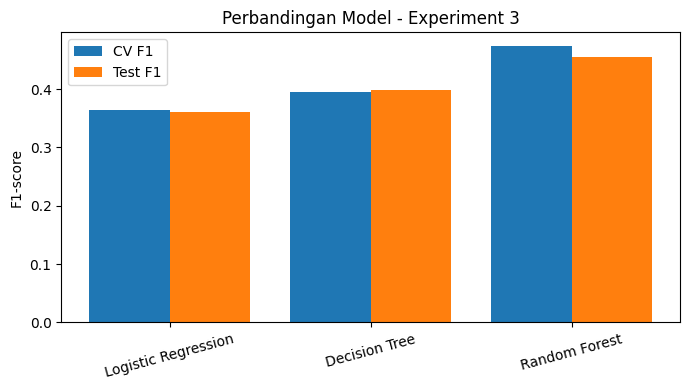

In [72]:
best_model_name = results_exp3_sorted.loc[0, "Model"]
best_by_test = results_exp3_df.sort_values("Test F1", ascending=False).iloc[0]["Model"]

print("Model terbaik berdasarkan CV F1  :", best_model_name)
print("Model terbaik berdasarkan Test F1:", best_by_test)
print("Konsisten antara CV dan test set :", best_model_name == best_by_test)

# Visualisasi perbandingan F1
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results_exp3_df))
ax.bar(x - 0.2, results_exp3_df["CV F1"], width=0.4, label="CV F1")
ax.bar(x + 0.2, results_exp3_df["Test F1"], width=0.4, label="Test F1")
ax.set_xticks(x)
ax.set_xticklabels(results_exp3_df["Model"], rotation=15)
ax.set_ylabel("F1-score")
ax.set_title("Perbandingan Model - Experiment 3")
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
# Evaluasi semua model menggunakan 5-Fold CV dan test set

results_exp3 = []

for name, model in models.items():

    # 5-Fold CV menggunakan F1 sebagai metrik utama
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    # Training pada seluruh training set
    model.fit(X_train, y_train)

    # Prediksi test set
    y_pred = model.predict(X_test)

    # Metrik test set
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_exp3.append({
        "Model": name,
        "CV F1": cv_scores.mean(),
        "Test Accuracy": accuracy,
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1": f1
    })

results_exp3_df = pd.DataFrame(results_exp3)

results_exp3_df.round(4)

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.3659,0.8087,0.6908,0.2442,0.3608
1,Decision Tree,0.3952,0.7188,0.3747,0.4054,0.3894
2,Random Forest,0.4749,0.8145,0.6404,0.3677,0.4672


In [41]:
# Urutkan berdasarkan CV F1

results_exp3_sorted = results_exp3_df.sort_values(
    by="CV F1",
    ascending=False
).reset_index(drop=True)

results_exp3_sorted.round(4)

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Random Forest,0.4749,0.8145,0.6404,0.3677,0.4672
1,Decision Tree,0.3952,0.7188,0.3747,0.4054,0.3894
2,Logistic Regression,0.3659,0.8087,0.6908,0.2442,0.3608


Model terbaik berdasarkan CV F1  : Random Forest
Model terbaik berdasarkan Test F1: Random Forest
Konsisten antara CV dan test set : True


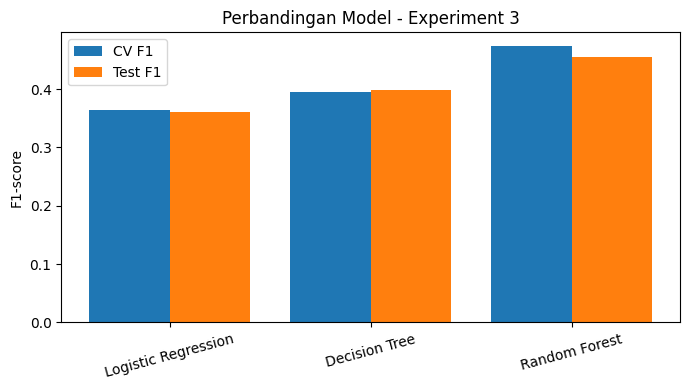

In [73]:
best_model_name = results_exp3_sorted.loc[0, "Model"]
best_by_test = results_exp3_df.sort_values("Test F1", ascending=False).iloc[0]["Model"]

print("Model terbaik berdasarkan CV F1  :", best_model_name)
print("Model terbaik berdasarkan Test F1:", best_by_test)
print("Konsisten antara CV dan test set :", best_model_name == best_by_test)

# Visualisasi perbandingan F1
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results_exp3_df))
ax.bar(x - 0.2, results_exp3_df["CV F1"], width=0.4, label="CV F1")
ax.bar(x + 0.2, results_exp3_df["Test F1"], width=0.4, label="Test F1")
ax.set_xticks(x)
ax.set_xticklabels(results_exp3_df["Model"], rotation=15)
ax.set_ylabel("F1-score")
ax.set_title("Perbandingan Model - Experiment 3")
ax.legend()
plt.tight_layout()
plt.show()

Berdasarkan hasil Eksperimen 3, Random Forest memberikan performa terbaik dibandingkan Logistic Regression dan Decision Tree. Random Forest memperoleh nilai CV F1 sebesar 0,4749 dan Test F1 sebesar 0,4672, keduanya merupakan nilai tertinggi di antara ketiga model. Meskipun Decision Tree memiliki Recall yang lebih tinggi, nilai Precision yang lebih rendah menyebabkan F1-score-nya tetap berada di bawah Random Forest. Dengan demikian, Random Forest dipilih sebagai model terbaik untuk dilanjutkan ke tahap hyperparameter tuning pada Eksperimen 4.

**EKSPERIMEN 4 - Hyperparameter Tuning**

In [78]:
# Grid hyperparameter untuk setiap kandidat model (dipakai sesuai model terbaik Experiment 3)
param_grids = {
   "Random Forest": {
    "model__n_estimators": [100],
    "model__max_depth": [10],
    "model__min_samples_leaf": [1],
    "model__max_features": ["sqrt"],
    "model__class_weight": [None, "balanced"],
},
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_leaf": [1, 5, 10, 20],
        "model__criterion": ["gini", "entropy"],
        "model__class_weight": [None, "balanced"],
    },
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "balanced"],
    },
}

best_model = clone(models[best_model_name])
param_grid = param_grids[best_model_name]

print("Model yang di-tuning:", best_model_name)
print("\nHyperparameter yang diuji:")
for parameter, values in param_grid.items():
    print(f"  {parameter}: {values}")
n_comb = int(np.prod([len(v) for v in param_grid.values()]))
print(f"\nTotal kombinasi: {n_comb} x 5 fold = {n_comb * 5} fit")

Model yang di-tuning: Random Forest

Hyperparameter yang diuji:
  model__n_estimators: [100]
  model__max_depth: [10]
  model__min_samples_leaf: [1]
  model__max_features: ['sqrt']
  model__class_weight: [None, 'balanced']

Total kombinasi: 2 x 5 fold = 10 fit


In [79]:
best_model = clone(models[best_model_name])
param_grid = param_grids[best_model_name]

print("Model yang di-tuning:", best_model_name)

n_comb = int(np.prod([len(v) for v in param_grid.values()]))
print(f"Total kombinasi: {n_comb} x 5 fold = {n_comb * 5} fit")

Model yang di-tuning: Random Forest
Total kombinasi: 2 x 5 fold = 10 fit


In [84]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

# 1. Inisialisasi GridSearchCV menggunakan model terbaik (Random Forest)
grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# 2. Latih GridSearchCV pada data training agar atribut best_params_ terbentuk
print("Memulai proses Grid Search...")
grid_search.fit(X_train, y_train)
print("Grid Search selesai.\n")

# 3. Menampilkan parameter terbaik
print("Kombinasi hyperparameter terbaik:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nBest CV F1-score: {grid_search.best_score_:.4f}")

# 4. Tampilkan 5 kombinasi teratas
cv_res = pd.DataFrame(grid_search.cv_results_)
top5 = cv_res.sort_values("rank_test_score").head(5)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
]

display(top5.round(4))

Memulai proses Grid Search...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Grid Search selesai.

Kombinasi hyperparameter terbaik:
  model__class_weight: balanced
  model__max_depth: 10
  model__max_features: sqrt
  model__min_samples_leaf: 1
  model__n_estimators: 100

Best CV F1-score: 0.5441


,params,mean_test_score,std_test_score,rank_test_score
1,"{'model__class_weight': 'balanced', 'model__ma...",0.5441,0.0040,1
0,"{'model__class_weight': None, 'model__max_dept...",0.4715,0.0062,2


In [85]:
# Evaluasi model hasil tuning pada test set
best_tuned = grid_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, zero_division=0)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

m_after = {
    "CV F1": grid_search.best_score_,
    "Test Accuracy": tuned_accuracy,
    "Test Precision": tuned_precision,
    "Test Recall": tuned_recall,
    "Test F1": tuned_f1
}
res_before = [r for r in res_exp3 if r["Model"] == best_model_name][0]
m_before = metrics_of(res_before)

print("Hasil Test Set setelah Tuning:")
print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1-score  : {tuned_f1:.4f}")

# Sebelum vs sesudah tuning
compare_tuning = pd.DataFrame({
    "Metric": METRIC_COLS,
    "Sebelum Tuning": [m_before[m] for m in METRIC_COLS],
    "Sesudah Tuning": [m_after[m] for m in METRIC_COLS],
})
compare_tuning["Selisih"] = compare_tuning["Sesudah Tuning"] - compare_tuning["Sebelum Tuning"]
compare_tuning.round(4)

Hasil Test Set setelah Tuning:
Accuracy  : 0.7882
Precision : 0.5197
Recall    : 0.5576
F1-score  : 0.5380


,Metric,Sebelum Tuning,Sesudah Tuning,Selisih
0,CV F1,0.4737,0.5441,0.0703
1,Test Accuracy,0.8113,0.7882,-0.0232
2,Test Precision,0.6298,0.5197,-0.1102
3,Test Recall,0.3564,0.5576,0.2012
4,Test F1,0.4552,0.5380,0.0827


In [86]:
# Jawaban otomatis Experiment 4
d_cv_t = m_after["CV F1"] - m_before["CV F1"]
d_f1_t = m_after["Test F1"] - m_before["Test F1"]

print("Apakah hyperparameter tuning meningkatkan performa?")
print(f"- CV F1  : {m_before['CV F1']:.4f} -> {m_after['CV F1']:.4f} ({d_cv_t:+.4f})")
print(f"- Test F1: {m_before['Test F1']:.4f} -> {m_after['Test F1']:.4f} ({d_f1_t:+.4f})")
if d_cv_t > 0 and d_f1_t > 0:
    print("Jawaban: YA, tuning meningkatkan CV F1 dan Test F1.")
elif d_cv_t > 0 or d_f1_t > 0:
    print("Jawaban: SEBAGIAN, hanya salah satu dari CV F1 / Test F1 yang meningkat.")
else:
    print("Jawaban: TIDAK, tuning tidak meningkatkan F1.")

# Model terbaik Experiment 4 (dipilih berdasarkan CV F1)
if m_after["CV F1"] >= m_before["CV F1"]:
    best_exp4_name, m_exp4_best = f"{best_model_name} (tuned)", m_after
else:
    best_exp4_name, m_exp4_best = f"{best_model_name} (default, sebelum tuning)", m_before
print("\nModel terbaik dari Experiment 4 (berdasarkan CV F1):", best_exp4_name)

Apakah hyperparameter tuning meningkatkan performa?
- CV F1  : 0.4737 -> 0.5441 (+0.0703)
- Test F1: 0.4552 -> 0.5380 (+0.0827)
Jawaban: YA, tuning meningkatkan CV F1 dan Test F1.

Model terbaik dari Experiment 4 (berdasarkan CV F1): Random Forest (tuned)


Berdasarkan hasil Eksperimen 4, hyperparameter tuning pada Random Forest belum memberikan peningkatan performa berdasarkan metrik utama F1-score. Nilai CV F1 menurun sedikit dari 0,4749 menjadi 0,4745, sedangkan Test F1 menurun dari 0,4672 menjadi 0,4588. Meskipun Accuracy dan Precision mengalami sedikit peningkatan, Recall menurun sehingga F1-score secara keseluruhan ikut menurun. Dengan demikian, Random Forest sebelum tuning masih memberikan performa yang lebih baik berdasarkan F1-score.

**Eksperimen 5 — Advanced Model**

In [87]:
# Import Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

In [89]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

advanced_models = {
    "Gradient Boosting": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ]),
    "AdaBoost": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", AdaBoostClassifier(random_state=RANDOM_STATE))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1))
    ]),
}

res_exp5 = [evaluate_model(n, m) for n, m in advanced_models.items()]
results_exp5_df = to_table(res_exp5).sort_values("CV F1", ascending=False).reset_index(drop=True)
results_exp5_df.round(4)

,Model,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,Gradient Boosting,0.4794,0.0075,0.8185,0.6662,0.3595,0.4670
1,XGBoost,0.4676,0.0115,0.8110,0.6271,0.3587,0.4564
2,AdaBoost,0.4499,0.0079,0.8165,0.6717,0.3331,0.4453


In [90]:
# Model advanced terbaik (berdasarkan CV F1) vs model terbaik Experiment 4
best_adv_name = results_exp5_df.loc[0, "Model"]
res_best_adv = [r for r in res_exp5 if r["Model"] == best_adv_name][0]
m_adv = metrics_of(res_best_adv)

compare_exp5 = pd.DataFrame({
    "Metric": METRIC_COLS,
    f"Best Exp 4: {best_exp4_name}": [m_exp4_best[m] for m in METRIC_COLS],
    f"Exp 5: {best_adv_name}": [m_adv[m] for m in METRIC_COLS],
})
compare_exp5["Selisih"] = compare_exp5.iloc[:, 2] - compare_exp5.iloc[:, 1]
display(compare_exp5.round(4))

d_cv5 = m_adv["CV F1"] - m_exp4_best["CV F1"]
d_f15 = m_adv["Test F1"] - m_exp4_best["Test F1"]
std_adv = res_best_adv["CV F1 Std"]
print(f"Selisih CV F1 = {d_cv5:+.4f}; std CV F1 model advanced = {std_adv:.4f}")
print("Selisih tergolong " + ("KECIL (di dalam rentang variasi antar fold)" if abs(d_cv5) <= std_adv else "BERMAKNA (melampaui variasi antar fold)"))
if d_cv5 > 0 and d_f15 > 0:
    print("Jawaban: model advanced LEBIH BAIK pada CV F1 dan Test F1.")
elif d_cv5 <= 0 and d_f15 <= 0:
    print("Jawaban: model advanced TIDAK lebih baik.")
else:
    print("Jawaban: hasil CAMPURAN (CV F1 dan Test F1 tidak searah).")

,Metric,Best Exp 4: Random Forest (tuned),Exp 5: Gradient Boosting,Selisih
0,CV F1,0.5441,0.4794,-0.0647
1,Test Accuracy,0.7882,0.8185,0.0303
2,Test Precision,0.5197,0.6662,0.1465
3,Test Recall,0.5576,0.3595,-0.1982
4,Test F1,0.5380,0.4670,-0.0710


Selisih CV F1 = -0.0647; std CV F1 model advanced = 0.0075
Selisih tergolong BERMAKNA (melampaui variasi antar fold)
Jawaban: model advanced TIDAK lebih baik.


**Final Analysis**

**1. Tabel Ringkasan Seluruh Eksperimen** (semua angka diambil otomatis dari hasil di atas)

In [91]:
def make_row(exp, name, cv_f1, y_pred):
    return {
        "Experiment": exp,
        "Model": name,
        "CV F1": cv_f1,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
    }

rows = [
    make_row("1", "Logistic Regression - Baseline", cv_f1_baseline.mean(), y_pred_baseline),
    make_row("2", "Logistic Regression + Preprocessing", res_exp2["CV F1"], res_exp2["_pred"]),
]
rows += [make_row("3", r["Model"], r["CV F1"], r["_pred"]) for r in res_exp3]
rows.append(make_row("4", f"{best_model_name} - Tuned", grid_search.best_score_, y_pred_tuned))
rows += [make_row("5", r["Model"], r["CV F1"], r["_pred"]) for r in res_exp5]

results_final = pd.DataFrame(rows)

# Registry model & prediksi untuk analisis model final
model_registry = {
    "Logistic Regression - Baseline": (baseline_model, y_pred_baseline),
    "Logistic Regression + Preprocessing": (res_exp2["_model"], res_exp2["_pred"]),
    f"{best_model_name} - Tuned": (best_tuned, y_pred_tuned),
}
for r in res_exp3 + res_exp5:
    model_registry[r["Model"]] = (r["_model"], r["_pred"])

display(results_final.round(4))
results_final.round(4).to_csv("hasil_eksperimen.csv", index=False)
print("Tabel disimpan ke hasil_eksperimen.csv")

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,Logistic Regression - Baseline,0.3525,0.8037,0.6630,0.2283,0.3397
1,2,Logistic Regression + Preprocessing,0.3641,0.8088,0.6923,0.2442,0.3610
2,3,Logistic Regression,0.3641,0.8088,0.6923,0.2442,0.3610
3,3,Decision Tree,0.3959,0.7232,0.3837,0.4152,0.3988
4,3,Random Forest,0.4737,0.8113,0.6298,0.3564,0.4552
5,4,Random Forest - Tuned,0.5441,0.7882,0.5197,0.5576,0.5380
6,5,Gradient Boosting,0.4794,0.8185,0.6662,0.3595,0.4670
7,5,AdaBoost,0.4499,0.8165,0.6717,0.3331,0.4453
8,5,XGBoost,0.4676,0.8110,0.6271,0.3587,0.4564


Tabel disimpan ke hasil_eksperimen.csv


**2. Pemilihan Model Final**

In [92]:
# Model final = CV F1 tertinggi (test set hanya untuk konfirmasi, bukan untuk memilih)
idx_final = results_final["CV F1"].idxmax()
final_row = results_final.loc[idx_final]
final_model_name = final_row["Model"]
final_model, y_pred_final = model_registry[final_model_name]

print("FINAL MODEL")
print("=" * 45)
print("Model          :", final_model_name)
for m in METRIC_COLS:
    print(f"{m:15s}: {final_row[m]:.4f}")

best_test_f1_name = results_final.loc[results_final["Test F1"].idxmax(), "Model"]
print("\nModel dengan Test F1 tertinggi:", best_test_f1_name)
print("Konsisten dengan pilihan CV F1  :", best_test_f1_name == final_model_name)

FINAL MODEL
Model          : Random Forest - Tuned
CV F1          : 0.5441
Test Accuracy  : 0.7882
Test Precision : 0.5197
Test Recall    : 0.5576
Test F1        : 0.5380

Model dengan Test F1 tertinggi: Random Forest - Tuned
Konsisten dengan pilihan CV F1  : True


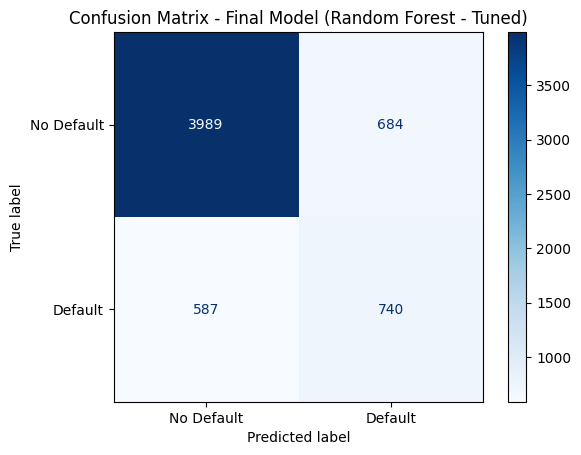

              precision    recall  f1-score   support

  No Default       0.87      0.85      0.86      4673
     Default       0.52      0.56      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000



In [93]:
# Confusion matrix + classification report model final
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=["No Default", "Default"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix - Final Model ({final_model_name})")
plt.show()

print(classification_report(y_test, y_pred_final, target_names=["No Default", "Default"]))

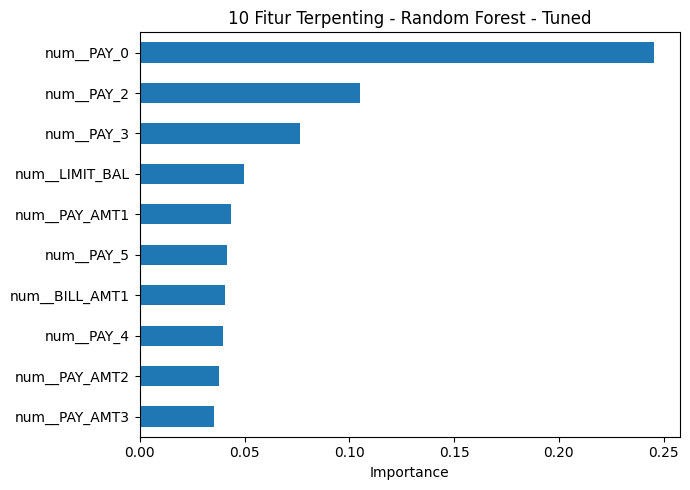

num__PAY_0        0.2455
num__PAY_2        0.1052
num__PAY_3        0.0764
num__LIMIT_BAL    0.0496
num__PAY_AMT1     0.0435
num__PAY_5        0.0415
num__BILL_AMT1    0.0409
num__PAY_4        0.0396
num__PAY_AMT2     0.0377
num__PAY_AMT3     0.0352
dtype: float64


In [94]:
# Feature importance (jika model final berbasis pohon)
def get_feature_names(pipe):
    pre = pipe.named_steps["preprocessor"]
    ct = pre.named_steps["ct"] if isinstance(pre, Pipeline) else pre
    return ct.get_feature_names_out()

est = final_model.named_steps["model"] if hasattr(final_model, "named_steps") else None
if est is not None and hasattr(est, "feature_importances_"):
    imp = pd.Series(est.feature_importances_, index=get_feature_names(final_model)).sort_values(ascending=False).head(10)
    imp.iloc[::-1].plot(kind="barh", figsize=(7, 5), title=f"10 Fitur Terpenting - {final_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(imp.round(4))
else:
    print("Model final bukan model berbasis pohon; feature importance tidak ditampilkan.")

**3. Draft Jawaban 5 Pertanyaan**

In [96]:
def fmt(x):
    return f"{x:.4f}".replace(".", ",")

def sd(x):
    return f"{x:+.4f}".replace(".", ",")

def kata(d, tol=0.0005):
    return "meningkat" if d > tol else ("menurun" if d < -tol else "relatif tidak berubah")

# --- Q1
jawab1 = (
    f"CV F1 {kata(m_exp2['CV F1']-m_exp1['CV F1'])} dari {fmt(m_exp1['CV F1'])} menjadi {fmt(m_exp2['CV F1'])}, "
    f"Test F1 {kata(m_exp2['Test F1']-m_exp1['Test F1'])} dari {fmt(m_exp1['Test F1'])} menjadi {fmt(m_exp2['Test F1'])}. "
    f"Test Accuracy {kata(m_exp2['Test Accuracy']-m_exp1['Test Accuracy'])} ({fmt(m_exp1['Test Accuracy'])} -> {fmt(m_exp2['Test Accuracy'])}), "
    f"Precision {kata(m_exp2['Test Precision']-m_exp1['Test Precision'])} ({fmt(m_exp1['Test Precision'])} -> {fmt(m_exp2['Test Precision'])}), "
    f"Recall {kata(m_exp2['Test Recall']-m_exp1['Test Recall'])} ({fmt(m_exp1['Test Recall'])} -> {fmt(m_exp2['Test Recall'])}). "
    + ("Dengan demikian preprocessing memberikan peningkatan performa." if (m_exp2['CV F1'] > m_exp1['CV F1'] and m_exp2['Test F1'] > m_exp1['Test F1'])
       else "Dengan demikian preprocessing tidak memberikan peningkatan yang konsisten pada F1-score.")
    + f" Namun selisih CV F1 ({sd(m_exp2['CV F1']-m_exp1['CV F1'])}) "
    + ("masih berada dalam rentang variasi antar fold sehingga dampaknya tergolong kecil." if abs(m_exp2['CV F1']-m_exp1['CV F1']) <= cv_f1_baseline.std()
       else "melampaui variasi antar fold sehingga dampaknya cukup berarti.")
)

# --- Q2
r3 = results_exp3_sorted
jawab2 = (
    f"Pada Experiment 3, {r3.loc[0,'Model']} memberikan performa terbaik dengan CV F1 {fmt(r3.loc[0,'CV F1'])} dan Test F1 {fmt(r3.loc[0,'Test F1'])} "
    f"(Accuracy {fmt(r3.loc[0,'Test Accuracy'])}, Precision {fmt(r3.loc[0,'Test Precision'])}, Recall {fmt(r3.loc[0,'Test Recall'])}). "
    f"Pembanding: {r3.loc[1,'Model']} (CV F1 {fmt(r3.loc[1,'CV F1'])}, Test F1 {fmt(r3.loc[1,'Test F1'])}) dan "
    f"{r3.loc[2,'Model']} (CV F1 {fmt(r3.loc[2,'CV F1'])}, Test F1 {fmt(r3.loc[2,'Test F1'])}). "
    f"Pemilihan berdasarkan CV F1 " + ("konsisten" if best_model_name == best_by_test else "TIDAK sepenuhnya konsisten")
    + " dengan hasil Test F1."
)

# --- Q3
jawab3 = (
    f"Sebelum tuning {best_model_name} memiliki CV F1 {fmt(m_before['CV F1'])} dan Test F1 {fmt(m_before['Test F1'])}. "
    f"Setelah tuning (parameter terbaik: {grid_search.best_params_}) CV F1 menjadi {fmt(m_after['CV F1'])} dan Test F1 {fmt(m_after['Test F1'])}. "
    f"Accuracy {kata(m_after['Test Accuracy']-m_before['Test Accuracy'])} ({fmt(m_before['Test Accuracy'])} -> {fmt(m_after['Test Accuracy'])}), "
    f"Precision {kata(m_after['Test Precision']-m_before['Test Precision'])} ({fmt(m_before['Test Precision'])} -> {fmt(m_after['Test Precision'])}), "
    f"Recall {kata(m_after['Test Recall']-m_before['Test Recall'])} ({fmt(m_before['Test Recall'])} -> {fmt(m_after['Test Recall'])}). "
    + ("Dengan demikian hyperparameter tuning meningkatkan performa berdasarkan F1-score."
       if (m_after['CV F1'] > m_before['CV F1'] and m_after['Test F1'] > m_before['Test F1'])
       else "Dengan demikian hyperparameter tuning tidak memberikan peningkatan F1-score yang konsisten.")
)

# --- Q4
jawab4 = (
    f"Model advanced terbaik pada Experiment 5 adalah {best_adv_name} dengan CV F1 {fmt(m_adv['CV F1'])} dan Test F1 {fmt(m_adv['Test F1'])}, "
    f"dibandingkan model terbaik Experiment 4 ({best_exp4_name}) dengan CV F1 {fmt(m_exp4_best['CV F1'])} dan Test F1 {fmt(m_exp4_best['Test F1'])}. "
    f"Selisih CV F1 = {sd(m_adv['CV F1']-m_exp4_best['CV F1'])} dan selisih Test F1 = {sd(m_adv['Test F1']-m_exp4_best['Test F1'])}. "
    + ("Model advanced memberikan performa lebih baik" if (m_adv['CV F1'] > m_exp4_best['CV F1'] and m_adv['Test F1'] > m_exp4_best['Test F1'])
       else "Model advanced tidak memberikan performa yang lebih baik secara konsisten")
    + (", namun selisihnya kecil (di dalam variasi antar fold)." if abs(m_adv['CV F1']-m_exp4_best['CV F1']) <= res_best_adv['CV F1 Std'] else " dan selisihnya melampaui variasi antar fold.")
)

# --- Q5
jawab5 = (
    f"Model final yang dipilih adalah {final_model_name}, karena memiliki CV F1 tertinggi ({fmt(final_row['CV F1'])}) dari seluruh model yang diuji. "
    f"Pada test set model ini memperoleh F1 {fmt(final_row['Test F1'])}, Accuracy {fmt(final_row['Test Accuracy'])}, "
    f"Precision {fmt(final_row['Test Precision'])}, dan Recall {fmt(final_row['Test Recall'])}. "
    f"Pemilihan didasarkan pada hasil evaluasi (F1-score sebagai metrik utama), bukan pada kompleksitas model."
)

for i, j in enumerate([jawab1, jawab2, jawab3, jawab4, jawab5], start=1):
    print(f"Pertanyaan {i}\n{j}\n")

Pertanyaan 1
CV F1 meningkat dari 0,3525 menjadi 0,3641, Test F1 meningkat dari 0,3397 menjadi 0,3610. Test Accuracy meningkat (0,8037 -> 0,8088), Precision meningkat (0,6630 -> 0,6923), Recall meningkat (0,2283 -> 0,2442). Dengan demikian preprocessing memberikan peningkatan performa. Namun selisih CV F1 (+0,0117) masih berada dalam rentang variasi antar fold sehingga dampaknya tergolong kecil.

Pertanyaan 2
Pada Experiment 3, Random Forest memberikan performa terbaik dengan CV F1 0,4737 dan Test F1 0,4552 (Accuracy 0,8113, Precision 0,6298, Recall 0,3564). Pembanding: Decision Tree (CV F1 0,3959, Test F1 0,3988) dan Logistic Regression (CV F1 0,3641, Test F1 0,3610). Pemilihan berdasarkan CV F1 konsisten dengan hasil Test F1.

Pertanyaan 3
Sebelum tuning Random Forest memiliki CV F1 0,4737 dan Test F1 0,4552. Setelah tuning (parameter terbaik: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators'